全 R 点数       : 19
有効 (R>0,finite): 19
物理レンジ [0.1, 10.0] 内: 19
ロバストカット後点数: 19

=== R 異方性フィット結果 ===
  使用 R: R_int_lin (e-integrated)
  データ点数 (最終): 19
  I0 (平均 logR)         ≈ -0.450
  I2 (cos2成分の振幅)   ≈ 0.128
  φ_R (logR 最大方向)    ≈ -85.2 deg
  R_max/R_min (モデル上) ≈ 1.29


/tmp/ipykernel_87911/3359253842.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(infile, comment='#', delim_whitespace=True, header=None)


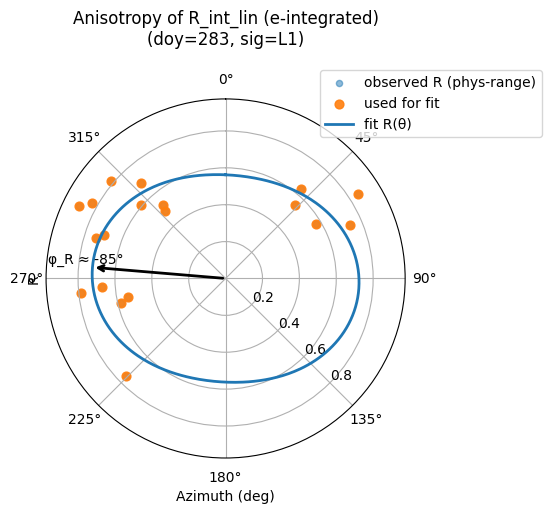

R_int_lin から計算した T (σ_h=0.050 m) を列 'T_from_R_int_lin_sigma0p050m' として追加しました。
R_int_lin から計算した T (σ_h=0.100 m) を列 'T_from_R_int_lin_sigma0p100m' として追加しました。
R_int_lin から計算した T (σ_h=0.400 m) を列 'T_from_R_int_lin_sigma0p400m' として追加しました。


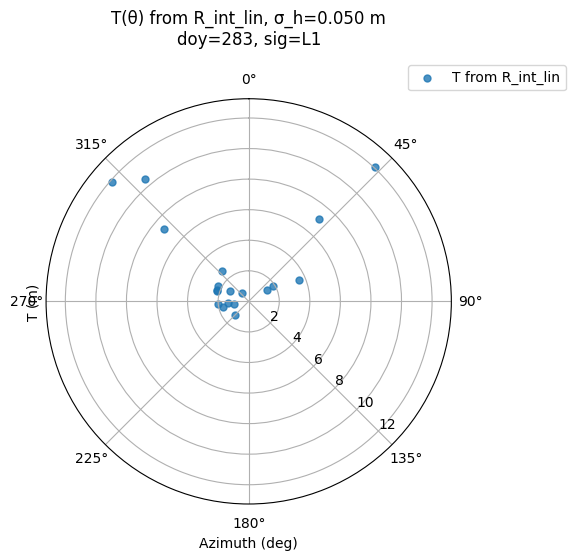

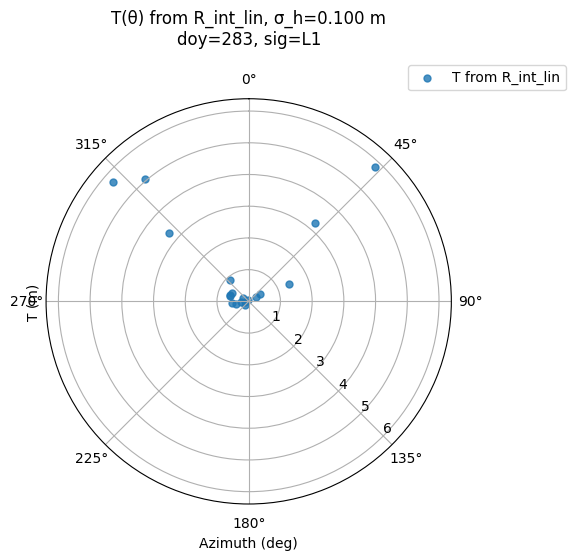

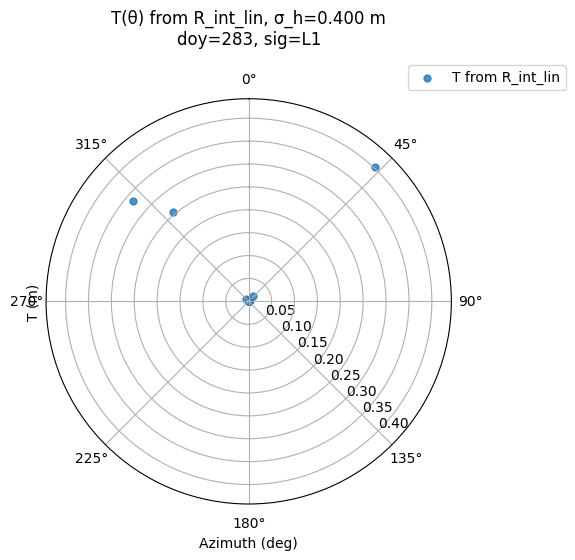

CSV に書き出しました: ./R_results/R_summary_doy283_L1_withR_T.csv


In [38]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpmath as mp  # T計算で S(g) を出すのに使う

# ========================
# 1. 入力・パラメータ設定
# ========================

infile = "./R_results/R_summary_doy283_L1.res"   # 入力 .res ファイル
outfile = "./R_results/R_summary_doy283_L1_withR_T.csv" # 出力ファイル

# どの R を使うか
USE_R_INT = True   # True  -> e で積分した比率 R_int_lin を使う
                   # False -> 中央仰角の R_mid_lin を使う

# 絶対的な物理レンジ（これを超えたら問答無用で捨てる：異方性フィット用）
R_MIN_PHYS = 0.1   # これ未満は「ほぼコヒーレントだけ or 計算ミス」
R_MAX_PHYS = 10.0  # これより大きい R_int は基本疑ってよい

# ロバスト外れ値カット用 (logR の中央値からのズレで判定)
MAD_CLIP_K = 3.0   # |logR - median(logR)| <= K * MAD だけ残す

# ====== ここから: R -> T 変換用パラメータ ======
COMPUTE_T_FROM_R = True      # True にすると R から T を計算して df に列を追加
LAMBDA_L1 = 0.190293672798365  # [m] GNSS L1 の波長

# 複数の σ_h で T を計算する
SIGMA_H_LIST = [0.05, 0.10, 0.40]  # [m] 好きな値を並べる
# ======================

# ======================
# 2. データ読み込み
# ======================

df = pd.read_csv(infile, comment='#', delim_whitespace=True, header=None)
df.columns = [
    "doy", "sat", "sig_code", "az_mid_deg", "e_mid_deg",
    "R_mid_lin", "R_mid_dB",
    "R_int_lin", "R_int_dB",
    "t_start_hour", "t_end_hour",
    "e_start_deg", "e_end_deg", "h0_m"
]

for c in ["az_mid_deg", "e_mid_deg", "R_mid_lin", "R_mid_dB",
          "R_int_lin", "R_int_dB"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ==========================
# 3. 異方性フィット用の関数
# ==========================

def fit_logR_anisotropy(theta_rad, logR_vals):
    """
    logR(θ) = I0 + I2 cos 2(θ - φ)
            = a0 + a1 cos 2θ + a2 sin 2θ
    を最小二乗でフィットして I0, I2, φ を返す。
    """
    theta_rad = np.asarray(theta_rad)
    logR_vals = np.asarray(logR_vals)

    X = np.column_stack([
        np.ones_like(theta_rad),
        np.cos(2.0 * theta_rad),
        np.sin(2.0 * theta_rad),
    ])
    y = logR_vals

    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    a0, a1, a2 = coef

    I0 = a0
    I2 = math.hypot(a1, a2)
    phi = 0.5 * math.atan2(a2, a1)

    return I0, I2, phi, coef

# ==========================
# 4. R を取り出してフィット
# ==========================

# 使う R を選択
if USE_R_INT:
    R_raw = df["R_int_lin"].values
    which_R = "R_int_lin (e-integrated)"
else:
    R_raw = df["R_mid_lin"].values
    which_R = "R_mid_lin (mid-elevation)"

az_deg = df["az_mid_deg"].values

# 有効値 + 物理レンジでマスク（異方性フィット用）
mask_valid = (
    np.isfinite(R_raw) &
    np.isfinite(az_deg) &
    (R_raw > 0)
)

R_valid = R_raw[mask_valid]
az_valid_deg = az_deg[mask_valid]

# 物理レンジでさらに絞る
mask_phys = (R_valid >= R_MIN_PHYS) & (R_valid <= R_MAX_PHYS)
R_phys = R_valid[mask_phys]
az_phys_deg = az_valid_deg[mask_phys]

print(f"全 R 点数       : {len(R_raw)}")
print(f"有効 (R>0,finite): {len(R_valid)}")
print(f"物理レンジ [{R_MIN_PHYS}, {R_MAX_PHYS}] 内: {len(R_phys)}")

if len(R_phys) < 5:
    raise RuntimeError("物理レンジ内の R データ点が少なすぎます。")

# logR を計算
logR = np.log(R_phys)

# --- ロバスト外れ値カット (median + MAD) ---
median_logR = np.median(logR)
abs_dev = np.abs(logR - median_logR)
MAD = np.median(abs_dev)

if MAD > 0:
    thresh = MAD_CLIP_K * MAD
    mask_robust = abs_dev <= thresh
else:
    # 全部同じ値に近い場合はそのまま
    mask_robust = np.ones_like(logR, dtype=bool)

logR_clip = logR[mask_robust]
az_clip_deg = az_phys_deg[mask_robust]

print(f"ロバストカット後点数: {len(logR_clip)}")

if len(logR_clip) < 5:
    raise RuntimeError("外れ値カット後の R データ点が少なすぎます。")

theta = np.deg2rad(az_clip_deg)

# フィット
I0, I2, phi_dir, coef = fit_logR_anisotropy(theta, logR_clip)

print("\n=== R 異方性フィット結果 ===")
print(f"  使用 R: {which_R}")
print(f"  データ点数 (最終): {len(logR_clip)}")
print(f"  I0 (平均 logR)         ≈ {I0:.3f}")
print(f"  I2 (cos2成分の振幅)   ≈ {I2:.3f}")
print(f"  φ_R (logR 最大方向)    ≈ {math.degrees(phi_dir):.1f} deg")

R_max_model = math.exp(I0 + I2)
R_min_model = math.exp(I0 - I2)
if R_min_model > 0:
    anisotropy_ratio = R_max_model / R_min_model
    print(f"  R_max/R_min (モデル上) ≈ {anisotropy_ratio:.2f}")
else:
    print("  R_min_model <= 0 なので R_max/R_min は計算せず。")

# ==========================
# 5. R の極座標プロット
# ==========================

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="polar")

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# 観測 R（物理レンジ内）を全部描く
theta_all = np.deg2rad(az_phys_deg)
ax.scatter(theta_all, R_phys, s=20, alpha=0.5, label="observed R (phys-range)")

# フィットに使った点だけ少し目立たせる
theta_used = np.deg2rad(az_clip_deg)
R_used = np.exp(logR_clip)
ax.scatter(theta_used, R_used, s=40, alpha=0.9, label="used for fit")

# フィットしたパターン
theta_grid = np.linspace(0, 2 * math.pi, 360)
logR_model = I0 + I2 * np.cos(2.0 * (theta_grid - phi_dir))
R_model = np.exp(logR_model)
ax.plot(theta_grid, R_model, linewidth=2.0, label="fit R(θ)")

# logR 最大方向に矢印
ax.annotate(
    "",
    xy=(phi_dir, R_model.max()),
    xytext=(phi_dir, 0),
    arrowprops=dict(arrowstyle="->", linewidth=2),
)
ax.text(
    phi_dir,
    R_model.max() * 1.05,
    f"φ_R ≈ {math.degrees(phi_dir):.0f}°",
    ha="center",
    va="bottom",
)

ax.set_title(f"Anisotropy of {which_R}\n(doy={int(df['doy'].iloc[0])}, sig=L1)", pad=20)
ax.set_rmax(1.1 * np.nanmax(np.concatenate([R_phys, R_model])))
ax.set_rlabel_position(135)
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("R")

ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))

plt.tight_layout()
plt.show()

# ==========================
# 6. R から T を計算（複数 σ_h）して df に追加
# ==========================

def S_of_g(g: float) -> float:
    """S(g) = sum_{m>=1} g^m/(m! m) = Ei(g) - γ - ln g"""
    g_safe = max(g, 1e-12)
    return float(mp.ei(g_safe) - mp.euler - mp.log(g_safe))

def compute_T_from_R_single(e_deg: float, h0: float, R_val: float,
                            sigma_h: float, lam: float) -> float:
    """
    1行ぶんの (e_mid_deg, h0_m, R) から T を計算。
    R は R_mid_lin でも R_int_lin でも良い。
    """
    if not np.isfinite(R_val) or R_val <= 0:
        return np.nan
    if not np.isfinite(e_deg) or not np.isfinite(h0):
        return np.nan

    eps_rad = math.radians(e_deg)
    s_eps = math.sin(eps_rad)
    if s_eps <= 0.0:
        return np.nan

    # フレネル面積 A ≈ π λ h / sin ε
    A = math.pi * lam * h0 / s_eps

    # g = (4π σ_h sin ε / λ)^2
    g = (4.0 * math.pi * sigma_h * s_eps / lam) ** 2

    Sg = S_of_g(g)

    # T^2 = A R / (π S(g))
    T_sq = A * R_val / (math.pi * Sg)
    if T_sq <= 0.0 or not np.isfinite(T_sq):
        return np.nan

    return math.sqrt(T_sq)

T_colnames = []

if COMPUTE_T_FROM_R:
    if USE_R_INT:
        R_for_T = df["R_int_lin"].to_numpy()
        src_name = "R_int_lin"
    else:
        R_for_T = df["R_mid_lin"].to_numpy()
        src_name = "R_mid_lin"

    e_mid_all = df["e_mid_deg"].to_numpy()
    h0_all = df["h0_m"].to_numpy()

    for sigma_h in SIGMA_H_LIST:
        col_T_name = f"T_from_{src_name}_sigma{sigma_h:.3f}m".replace('.', 'p')
        T_list = []
        for e_deg, h0, R_val in zip(e_mid_all, h0_all, R_for_T):
            T_val = compute_T_from_R_single(
                e_deg, h0, R_val,
                sigma_h=sigma_h,
                lam=LAMBDA_L1
            )
            T_list.append(T_val)

        df[col_T_name] = np.array(T_list, dtype=float)
        T_colnames.append((sigma_h, col_T_name))
        print(f"{src_name} から計算した T (σ_h={sigma_h:.3f} m) を列 '{col_T_name}' として追加しました。")

# ==========================
# 7. T(θ) を σ_h ごとに極座標プロット
# ==========================

if COMPUTE_T_FROM_R and T_colnames:
    for sigma_h, col_T_name in T_colnames:
        T_vals = df[col_T_name].to_numpy()
        az_all = df["az_mid_deg"].to_numpy()

        mask_T = np.isfinite(T_vals) & (T_vals > 0) & np.isfinite(az_all)
        if np.count_nonzero(mask_T) < 3:
            print(f"σ_h={sigma_h:.3f} m: 有効な T データ点が少なすぎるためプロットスキップ")
            continue

        T_use = T_vals[mask_T]
        az_use_deg = az_all[mask_T]
        theta_T = np.deg2rad(az_use_deg)

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="polar")

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        ax.scatter(theta_T, T_use, s=25, alpha=0.8, label=f"T from {src_name}")

        ax.set_title(
            f"T(θ) from {src_name}, σ_h={sigma_h:.3f} m\n"
            f"doy={int(df['doy'].iloc[0])}, sig=L1",
            pad=20
        )
        ax.set_xlabel("Azimuth (deg)")
        ax.set_ylabel("T (m)")

        rmax_T = 1.1 * np.nanmax(T_use)
        ax.set_rmax(rmax_T)
        ax.set_rlabel_position(135)

        ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
        plt.tight_layout()
        plt.show()

# ==========================
# 8. CSV に保存
# ==========================

df.to_csv(outfile, index=False)
print("CSV に書き出しました:", outfile)
